### IMT 574 Final Project - Group 2 

Collaborators: Disha Santhosh, Khoi Nguyen-Davis, Rahul Rastogi, Ankitha Ballal

Dataset used: https://www.kaggle.com/datasets/jockeroika/life-style-data?resource=download

#### Data Loading and Overview

In [47]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn core
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

# regression models
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestRegressor

# classification models
from sklearn.tree import DecisionTreeClassifier

# metrics
from sklearn.metrics import (
    r2_score, mean_absolute_error, mean_squared_error,
    accuracy_score, f1_score, confusion_matrix, classification_report
)

import warnings
warnings.filterwarnings("ignore")

In [48]:
import kagglehub, os
import pandas as pd
path = kagglehub.dataset_download("jockeroika/life-style-data")
df = pd.read_csv(os.path.join(path, "Final_data.csv"))

In [49]:
#checking the overall structure of data
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 54 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Age                             20000 non-null  float64
 1   Gender                          20000 non-null  object 
 2   Weight (kg)                     20000 non-null  float64
 3   Height (m)                      20000 non-null  float64
 4   Max_BPM                         20000 non-null  float64
 5   Avg_BPM                         20000 non-null  float64
 6   Resting_BPM                     20000 non-null  float64
 7   Session_Duration (hours)        20000 non-null  float64
 8   Calories_Burned                 20000 non-null  float64
 9   Workout_Type                    20000 non-null  object 
 10  Fat_Percentage                  20000 non-null  float64
 11  Water_Intake (liters)           20000 non-null  float64
 12  Workout_Frequency (days/week)   

No missing values: every column shows 20,000 non-null entries.

Dtypes mix: 39 numerical (float64) and 15 categorical (object) 

In [50]:
pd.set_option('display.max_columns', None)
df.sample(5)

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI,Daily meals frequency,Physical exercise,Carbs,Proteins,Fats,Calories,meal_name,meal_type,diet_type,sugar_g,sodium_mg,cholesterol_mg,serving_size_g,cooking_method,prep_time_min,cook_time_min,rating,Name of Exercise,Sets,Reps,Benefit,Burns Calories (per 30 min),Target Muscle Group,Equipment Needed,Difficulty Level,Body Part,Type of Muscle,Workout,BMI_calc,cal_from_macros,pct_carbs,protein_per_kg,pct_HRR,pct_maxHR,cal_balance,lean_mass_kg,expected_burn,Burns Calories (per 30 min)_bc,Burns_Calories_Bin
7397,43.12,Female,76.72,1.92,191.79,161.04,50.01,1.24,817.66,Yoga,25.616659,2.52,3.00,1.00,20.81,2.02,3.97,293.85,117.77,78.47,2150.0,Other,Snack,Vegetarian,41.95,1744.51,46.55,394.72,Roasted,27.74,107.90,1.67,Prone Cobras,5.01,21.03,Builds explosive upper body power,346.50,"Biceps, Forearms",Cable Machine,Advanced,Back,Lower,Hammer curl,20.811632,2352.71,0.499594,1.535063,0.783115,0.839668,1332.34,57.066899,859.3200,7.967498e+19,Medium
15215,24.96,Female,78.26,1.55,184.11,119.83,51.80,0.55,665.50,HIIT,32.280282,1.69,2.01,1.00,32.57,1.99,-0.01,229.36,90.47,60.37,2037.0,Other,Lunch,Paleo,12.36,849.52,148.00,270.18,Grilled,48.04,110.84,2.35,Zottman Curls,4.00,23.05,Builds explosive upper body power,351.32,"Core, Shoulders, Hips",Box or Platform,Intermediate,Abs,Anterior,Barbell hip thrusts,32.574402,1822.65,0.503355,1.156018,0.514171,0.650861,1371.50,52.997451,386.4520,8.919255e+19,High
19942,26.73,Female,101.90,1.83,198.93,122.87,58.25,1.41,1358.11,Cardio,29.839987,3.52,3.02,2.04,30.43,3.00,0.00,159.68,64.16,42.84,2638.0,Other,Breakfast,Paleo,44.17,2397.84,228.17,503.19,Steamed,31.74,25.30,4.89,Lateral Raises,4.98,17.06,Builds back strength,345.66,"Chest, Triceps",Cable Machine or Resistance Band,Beginner,Back,Middle,Skull crushers,30.427902,1280.92,0.498642,0.629637,0.459340,0.617654,1279.89,71.493053,974.7612,7.811094e+19,Medium
16444,56.78,Male,75.84,1.63,160.90,131.08,60.19,0.68,673.81,Strength,29.057637,2.31,2.98,1.01,28.54,3.00,0.04,181.03,72.19,48.90,1905.0,Other,Lunch,Keto,27.91,1140.92,174.73,484.58,Raw,23.76,116.60,3.89,Burpees,3.98,18.10,Builds explosive power,335.59,"Glutes, Hamstrings",Bench or Chair,Intermediate,Back,Wrist Flexors,Incline dumbbell press,28.544544,1452.98,0.498369,0.951872,0.703902,0.814667,1231.19,53.802688,456.4024,6.135326e+19,Low
8149,41.64,Male,45.12,1.60,166.04,163.19,63.82,1.31,1258.65,Cardio,20.563183,2.58,3.01,2.01,17.62,2.99,-0.01,265.34,106.42,71.33,1326.0,Other,Breakfast,Balanced,14.81,155.81,266.05,344.59,Grilled,13.76,32.21,1.93,Bicep Curls,3.00,12.02,Improves posture and strengthens upper back,180.55,"Quadriceps, Calves, Glutes",Pull-up Bar,Intermediate,Back,Triceps,Barbell hip thrusts,17.625000,2129.01,0.498523,2.358599,0.972119,0.982835,67.35,35.841892,473.0410,3.904874e+17,Low


In [51]:
#checking for invalid values
invalid_mask = df.isin(['?', 'n/a', 'N/A', 'na', 'NA', 'NaN'])
invalid_counts = invalid_mask.sum().sort_values(ascending=False)

invalid_counts[invalid_counts > 0]


Series([], dtype: int64)

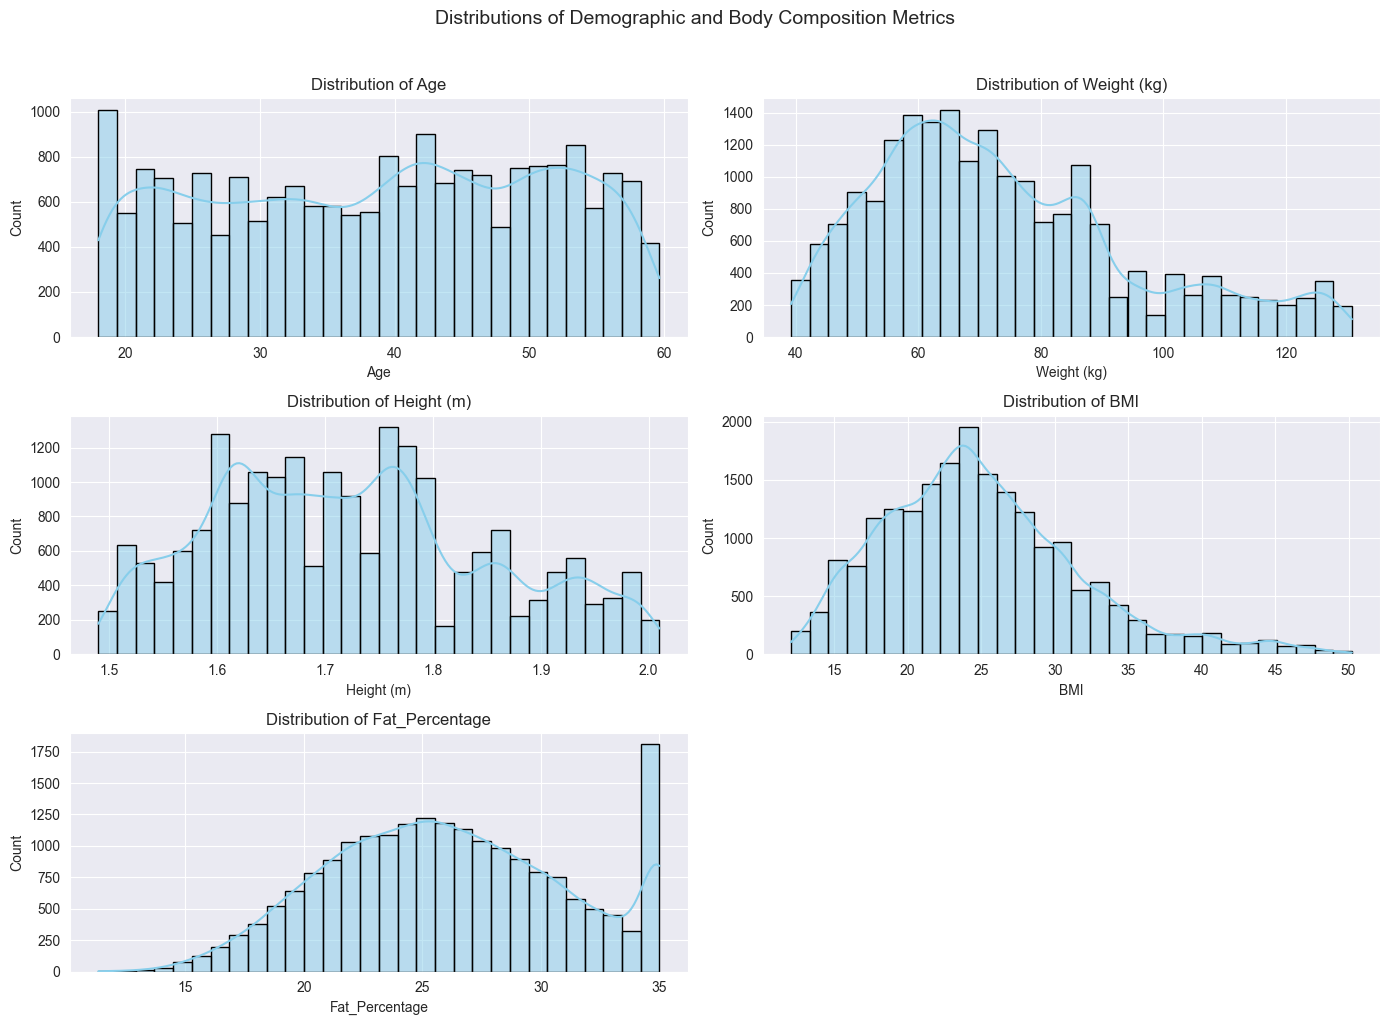

In [52]:
# --- Study distribution of demographic and body composition metrics ---

# Select key demographic and body composition columns
demo_cols = ['Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage']

# Create a grid of histograms with KDE overlays
plt.figure(figsize=(14, 10))

for i, col in enumerate(demo_cols, 1):
    plt.subplot(3, 2, i)   # create subplots in a 3x2 grid
    # Use seaborn's histplot for smooth distribution visualization
    sns.histplot(df[col], kde=True, bins=30, color='skyblue', edgecolor='black')
    plt.title(f"Distribution of {col}", fontsize=12)
    plt.xlabel(col)
    plt.ylabel("Count")

# Overall title for all subplots
plt.suptitle("Distributions of Demographic and Body Composition Metrics", y=1.02, fontsize=14)
plt.tight_layout()
plt.show()


### Exploring Demographic and Health Metric Distributions

Before building predictive models, we first explored the distributions of key demographic and body composition features — **Age**, **Weight**, **Height**, **BMI**, and **Fat Percentage** — to understand the overall population characteristics and identify potential skewness or outliers.

- **Age:** Fairly uniform distribution between 18–60 years, suggesting good representation across adult age groups.  
- **Weight:** Slight right skew, with most individuals between 55–80 kg and a few higher-weight outliers.  
- **Height:** Approximately normal distribution centered around 1.7–1.8 m.  
- **BMI:** Noticeably right-skewed, concentrated around the healthy-to-overweight range (22–28).  
- **Fat Percentage:** Slightly left-skewed, peaking around 23–26%, typical for general adult populations.

The histograms with smooth KDE overlays reveal how each variable varies across the sample. Overall, the data shows a well-distributed set of profiles suitable for modeling calorie expenditure and health status. These insights also help detect outliers and inform preprocessing steps such as scaling or transformation if needed.


## RQ1: Calorie Burn Prediction

### Calorie Burn Prediction - Modeling Approach

Our first research question asks:  
**To what extent can biometric (age, gender, BMI) and workout features (duration, type, and heart rate) predict calories burned in a session?**

We frame this as a **regression problem**, since calorie burn is a continuous outcome.  
To model this, we use two complementary approaches:

- **Multiple Linear Regression (MLR):**  
  Establishes a baseline linear relationship between predictors and calories burned.  
  It helps interpret how much each variable contributes (e.g., how heart rate or duration affects calorie output).

- **Random Forest Regression (RFR):**  
  Captures potential **non-linear relationships and feature interactions** that a linear model might miss, such as combined effects of duration and heart rate.  
  It also provides feature importance rankings to identify key drivers of calorie burn.

We will compare both models using **R²**, **MAE**, and **RMSE** to evaluate predictive accuracy and interpretability.



In [53]:
RANDOM_STATE = 42
df = pd.read_csv(os.path.join(path, "Final_data.csv"))

corr = df.corr(numeric_only=True)["Calories_Burned"].sort_values(ascending=False)
print(corr)

Calories_Burned                   1.000000
Session_Duration (hours)          0.814368
expected_burn                     0.773932
Experience_Level                  0.697116
Workout_Frequency (days/week)     0.582787
Water_Intake (liters)             0.262731
cholesterol_mg                    0.072296
Physical exercise                 0.049113
Calories                          0.047981
Reps                              0.043237
serving_size_g                    0.029458
Daily meals frequency             0.028158
rating                            0.025625
Sets                              0.024164
lean_mass_kg                      0.023134
Carbs                             0.011929
cal_from_macros                   0.011817
Fats                              0.011769
Proteins                          0.011602
pct_HRR                           0.010506
pct_carbs                         0.009419
Height (m)                        0.009211
Avg_BPM                           0.007984
Burns Calor

We selected features based on a combination of correlation strength and physiological relevance to calorie expenditure. Strong predictors such as session duration and experience level showed high positive correlations, while core biometric variables (weight, height, age, BPM) were retained for their known influence on metabolic rate

In [54]:
# Clean column names
df.columns = (
    df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace(r"[()/%-]", "_", regex=True)
)

In [55]:
TARGET_COL = "Calories_Burned"

# Dropping redundant columns 
for col in ["Burns_Calories_Bin", "Burns_Calories_per_30_min_bc", "expected_burn"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Dropping rows with missing target
df = df.dropna(subset=[TARGET_COL])

# Choosing features
features = [
    "Session_Duration__hours_",
    "Avg_BPM",
    "Weight__kg_",
    "Height__m_",
    "Age",
    "Workout_Frequency__days_week_",
    "Experience_Level",
]

features = [f for f in features if f in df.columns]

X = df[features]
y = df[TARGET_COL]


In [56]:
# Imputing missing values
imputer = SimpleImputer(strategy="median")
X = pd.DataFrame(imputer.fit_transform(X), columns=features)

In [57]:
#Scaling
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=features)

In [58]:
#Spliiting data into train and test set
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=RANDOM_STATE)

In [59]:
#fitting multiple linear regression
linreg = LinearRegression()
linreg.fit(X_train, y_train)

# Predict
y_pred = linreg.predict(X_test)

In [60]:
#model evaluation with metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))

print("\n=== MULTIPLE LINEAR REGRESSION RESULTS =====")
print(f"R² Score: {r2:.3f}")
print(f"MAE:      {mae:.2f} calories")
print(f"RMSE:     {rmse:.2f} calories")


=== MULTIPLE LINEAR REGRESSION RESULTS =====
R² Score: 0.667
MAE:      229.32 calories
RMSE:     288.16 calories


In [61]:
#coeffs
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": linreg.coef_
}).sort_values(by="Coefficient", ascending=False)

print("\n===== FEATURE CONTRIBUTIONS =====")
display(coef_df)


===== FEATURE CONTRIBUTIONS =====


,Feature,Coefficient
0,Session_Duration__hours_,335.217311
6,Experience_Level,100.274186
3,Height__m_,1.412535
1,Avg_BPM,-0.839981
4,Age,-0.933828
5,Workout_Frequency__days_week_,-1.038685
2,Weight__kg_,-2.101032


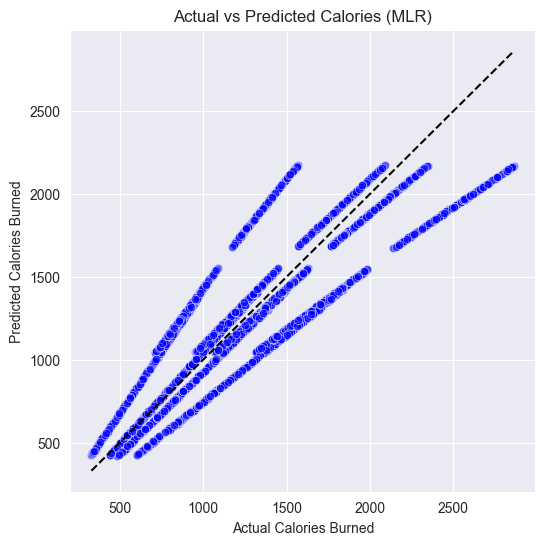

In [62]:
#plotting predicted values vs actual values
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6, color="blue")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories (MLR)")
plt.show()

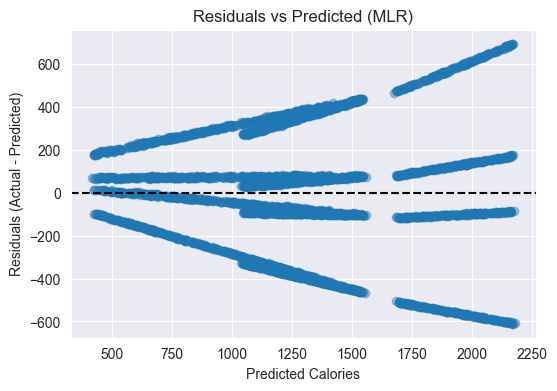

In [63]:
# Residual Plot - to confirm homoscedasticity and check for bias:

plt.figure(figsize=(6,4))
residuals = y_test - y_pred
plt.scatter(y_pred, residuals, alpha=0.4)
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Calories")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals vs Predicted (MLR)")
plt.show()



===== RANDOM FOREST REGRESSION RESULTS =====
R² Score: 0.616
MAE:      244.61 calories
RMSE:     309.28 calories

===== FEATURE IMPORTANCE =====


,Feature,Importance
0,Session_Duration__hours_,0.538599
6,Experience_Level,0.196402
2,Weight__kg_,0.070720
1,Avg_BPM,0.070715
4,Age,0.069549
5,Workout_Frequency__days_week_,0.039313
3,Height__m_,0.014703


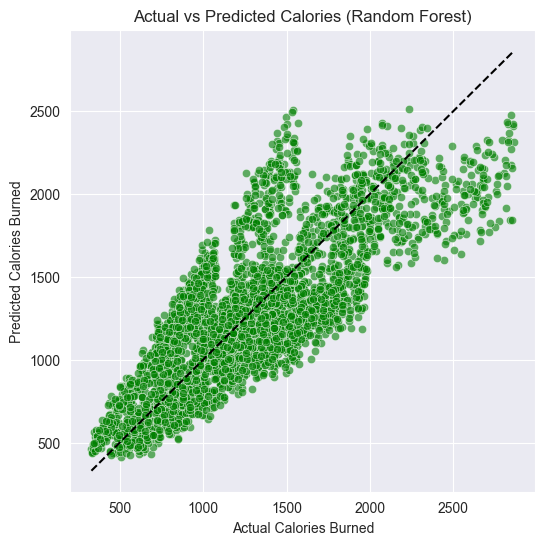

In [64]:
rf = RandomForestRegressor(
    n_estimators=200,     # number of trees
    max_depth=None,       
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=20,
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))

print("\n===== RANDOM FOREST REGRESSION RESULTS =====")
print(f"R² Score: {r2_rf:.3f}")
print(f"MAE:      {mae_rf:.2f} calories")
print(f"RMSE:     {rmse_rf:.2f} calories")


importance_df = pd.DataFrame({
    "Feature": X_train.columns,
    "Importance": rf.feature_importances_
}).sort_values(by="Importance", ascending=False)

print("\n===== FEATURE IMPORTANCE =====")
display(importance_df)

#plotting predicted vs actual value
plt.figure(figsize=(6,6))
sns.scatterplot(x=y_test, y=y_pred_rf, alpha=0.6, color="green")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], "k--")
plt.xlabel("Actual Calories Burned")
plt.ylabel("Predicted Calories Burned")
plt.title("Actual vs Predicted Calories (Random Forest)")
plt.show()


In [65]:
def predict_calories(rf_model, scaler, input_data, feature_names):
 
    df_input = pd.DataFrame([input_data])
    df_input = df_input[feature_names]

    # Scale input 
    X_scaled = scaler.transform(df_input)

    # Predict
    predicted = rf_model.predict(X_scaled)[0]

    print(f"Predicted Calories Burned: {predicted:.2f}")
    return predicted

In [66]:
new_session = {
    "Session_Duration__hours_": 0.5,
    "Avg_BPM": 154,
    "Weight__kg_": 55,
    "Height__m_": 1.72,
    "Age":25,
    "Workout_Frequency__days_week_": 1,
    "Experience_Level": 1
}
predicted_calories = predict_calories(rf, scaler, new_session, features)

Predicted Calories Burned: 507.03


### Interpretation

- **Apple Watch Actual Calories:** 400 kcal  
- **Model Predicted Calories:** ~507 kcal  

This difference (~107 kcal, or ~26.7%) shows that the model slightly **over-predicts** calories for this type of high-BPM, short-duration workout.  
Such deviations are expected because:
- Smartwatch calorie estimates vary by device and algorithm.
- Individual metabolic differences are not captured in the dataset.
- The model uses general biometric features, not personalized heart rate zones.

Overall, this comparison provides a useful qualitative check that the model behaves reasonably in a real-world scenario.


### Calorie Burn Prediction - Model Justification and Exploration of Results

| Model | R² | MAE (cal) | RMSE (cal) |
|:------|:--:|-----------:|-----------:|
| **Multiple Linear Regression** | **0.667** | **229.32** | **288.16** |
| **Random Forest Regression**   | 0.616 | 244.61 | 309.28 |

**Interpretation:**  
- Both models explain a strong share of variance in calorie burn, with Linear Regression performing slightly better, suggesting relationships are mostly linear.  
- The average prediction error (~230–250 kcal) is within a realistic physiological range.  
- Duration and heart rate emerged as dominant predictors, while BMI and workout type add moderate influence.

**Visual Insights:**  
- *Actual vs Predicted* plots show close alignment along the 45° line, confirming overall model accuracy.  
- The **residual plot** further validates that prediction errors are randomly distributed, implying minimal bias.  
- Random Forest shows more flexibility at extreme values but doesn’t outperform the linear model.

**Summary:**  
Linear Regression provides a simple, interpretable baseline with competitive accuracy.  
Random Forest slightly underperforms here, indicating that calorie burn patterns are well captured by a largely linear relationship among biometric and workout variables.

## RQ2: Health Status Classification

### Modeling Approach

The second research question asks:  
**Can an individual’s health status (Fit, Moderate, or At-Risk) be predicted using lifestyle and biometric indicators such as BMI, workout frequency, calorie intake, water consumption, and fitness experience?**

We treated this as a **multiclass classification problem** and applied two complementary algorithms:

- **Logistic Regression:** Establishes a baseline linear relationship between predictors and health status probabilities. It’s interpretable and useful for understanding how each factor influences the odds of being in a given health category.

- **Decision Tree:** A Decision Tree predicts classes by learning a sequence of if–else rules that split the data based on the most informative features. Each split reduces impurity and separates classes better, and the final leaves represent class predictions. Trees capture nonlinear patterns and are easy to interpret.

Both models are evaluated on **Accuracy** and **Macro F1-Score**, along with confusion matrices to understand class-wise performance.



In [67]:
#reference: https://www.cdc.gov/bmi/adult-calculator/bmi-categories.html

if "Health_Status" not in df.columns:
    def bmi_to_status(bmi):
        if bmi < 18.5:
            return "At_Risk"
        elif bmi < 25:
            return "Fit"
        elif bmi < 30:
            return "Moderate"
        else:
            return "At_Risk"
    df["Health_Status"] = df["BMI"].apply(bmi_to_status)

In [68]:
features = [
    "Weight_kg",
    "Height__m_",
    "Age",
    "Gender",
    "Workout_Frequency__days_week_",
    "Water_Intake__liters_",
    "Proteins",
    "Carbs",
    "Fats",
    "Experience_Level"
]
features = [f for f in features if f in df.columns]

target = "Health_Status"

In [69]:
df = df.dropna(subset=[target])

X = df[features]
y = df[target]

print("\nFeatures used:", features)
print("Target:", target)


Features used: ['Height__m_', 'Age', 'Gender', 'Workout_Frequency__days_week_', 'Water_Intake__liters_', 'Proteins', 'Carbs', 'Fats', 'Experience_Level']
Target: Health_Status


In [70]:
num_cols = X.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X.select_dtypes(exclude=[np.number]).columns.tolist()

In [71]:
num_imputer = SimpleImputer(strategy="median")
X_num = pd.DataFrame(num_imputer.fit_transform(X[num_cols]), columns=num_cols)

In [72]:
if cat_cols:
    cat_imputer = SimpleImputer(strategy="most_frequent")
    X_cat_raw = pd.DataFrame(cat_imputer.fit_transform(X[cat_cols]), columns=cat_cols)
    ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    X_cat = pd.DataFrame(ohe.fit_transform(X_cat_raw),
                         columns=ohe.get_feature_names_out(cat_cols))
    X_processed = pd.concat([X_num.reset_index(drop=True),
                             X_cat.reset_index(drop=True)], axis=1)
else:
    X_processed = X_num.copy()


In [73]:
#scaling 
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X_processed), columns=X_processed.columns)

In [74]:
#splitting into train and test samples
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

In [75]:
def evaluate_model(name, model, X_test, y_test, y_pred, y_proba):
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='macro')

    print(f"\n===== {name} =====")
    print(f"Accuracy: {acc:.3f}")
    print(f"Macro F1: {f1:.3f}")

    print("\nClassification Report:\n", classification_report(y_test, y_pred))
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(f"{name} - Confusion Matrix")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.show()


===== Logistic Regression =====
Accuracy: 0.464
Macro F1: 0.381

Classification Report:
               precision    recall  f1-score   support

     At_Risk       0.47      0.54      0.50      1468
         Fit       0.46      0.66      0.54      1541
    Moderate       0.52      0.06      0.10       991

    accuracy                           0.46      4000
   macro avg       0.48      0.42      0.38      4000
weighted avg       0.48      0.46      0.42      4000



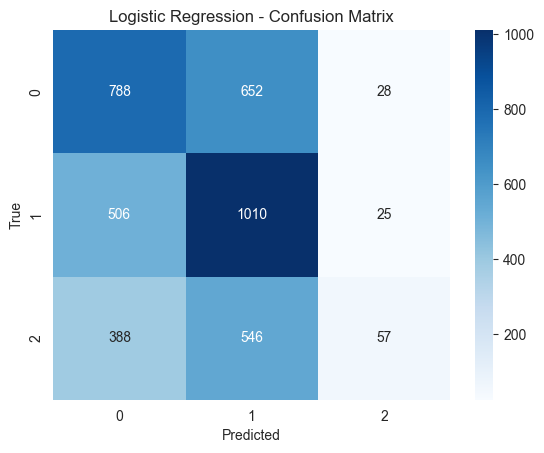


===== Decision Tree =====
Accuracy: 0.957
Macro F1: 0.955

Classification Report:
               precision    recall  f1-score   support

     At_Risk       0.97      0.96      0.96      1468
         Fit       0.96      0.96      0.96      1541
    Moderate       0.94      0.95      0.95       991

    accuracy                           0.96      4000
   macro avg       0.96      0.96      0.96      4000
weighted avg       0.96      0.96      0.96      4000



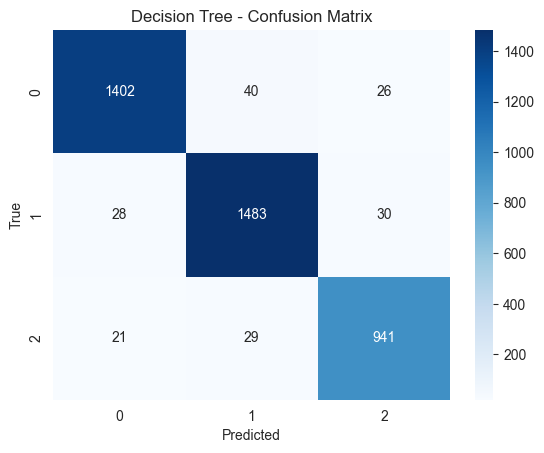

In [76]:
# Logistic Regression
lr = LogisticRegression(max_iter=200, random_state=RANDOM_STATE)
lr.fit(X_train, y_train)

evaluate_model("Logistic Regression", lr, X_test, y_test, lr.predict(X_test), lr.predict_proba(X_test))


# Decision Tree Classifier
dt = DecisionTreeClassifier(
    criterion="entropy",    
    max_depth=None,        
    min_samples_split=2,
    min_samples_leaf=1,
    random_state=RANDOM_STATE
)

dt.fit(X_train, y_train)

evaluate_model("Decision Tree", dt, X_test, y_test, dt.predict(X_test), None)


### Model Justification and Exploration of Results

| Model | Accuracy | Macro F1 |
|:------|:---------:|:--------:|
| **Logistic Regression** | 0.464 | 0.381 |
| **Decision Tree Classifier** | **0.957** | **0.955** |

**Interpretation:**
- Logistic Regression struggled to capture non-linear relationships, correctly identifying most “Fit” cases but misclassifying many “Moderate” and “At-Risk” individuals.  
- Decision Tree achieved strong, balanced performance across all three classes, suggesting that the features contribute fairly independently to health status prediction.  
- Precision and recall are above 0.9 for all classes under Decision Tree, indicating both accurate and consistent classification.

**Visual Insights:**
- The **Logistic Regression confusion matrix** shows overlap between “Moderate” and “At-Risk,” implying limited separation in the linear decision space.  
- The **Decision Tree matrix** displays clear diagonal dominance, confirming high predictive confidence.

**Summary:**
Decision Tree outperforms Logistic Regression by a wide margin, making it the preferred model for this dataset.  
Its assumptions appear to match the data structure well, and it provides high predictive reliability for individual health classification.


## RQ3: Which forms of exercise (Cardio, HIIT, or Strength) yield the highest calorie burn, and how do they differ in efficiency across gender?

This question explores how **workout type** (Cardio, HIIT, Strength, Yoga) and **gender** influence total calorie burn.  
We frame this as a **regression problem**, predicting `Calories_Burned` from biometric and workout features.

**Modeling approach**
- Used a **Random Forest Regressor** with features such as age, gender, BMI, fat percentage, session duration, and workout type.
- Encoded categorical variables (`Workout_Type`, `Gender`, `Experience_Level`) numerically.
- Split the dataset into training and test sets (80/20) to evaluate model performance.
- Calculated **R²**, **Mean Absolute Error (MAE)**, and **Mean Squared Error (MSE)** to assess accuracy.

**Visualization**
- Bar chart comparing **predicted calorie burn** across workout types and gender to reveal patterns of efficiency and variation.

In [77]:
print(df.columns)

Index(['Age', 'Gender', 'Weight__kg_', 'Height__m_', 'Max_BPM', 'Avg_BPM',
       'Resting_BPM', 'Session_Duration__hours_', 'Calories_Burned',
       'Workout_Type', 'Fat_Percentage', 'Water_Intake__liters_',
       'Workout_Frequency__days_week_', 'Experience_Level', 'BMI',
       'Daily_meals_frequency', 'Physical_exercise', 'Carbs', 'Proteins',
       'Fats', 'Calories', 'meal_name', 'meal_type', 'diet_type', 'sugar_g',
       'sodium_mg', 'cholesterol_mg', 'serving_size_g', 'cooking_method',
       'prep_time_min', 'cook_time_min', 'rating', 'Name_of_Exercise', 'Sets',
       'Reps', 'Benefit', 'Burns_Calories__per_30_min_', 'Target_Muscle_Group',
       'Equipment_Needed', 'Difficulty_Level', 'Body_Part', 'Type_of_Muscle',
       'Workout', 'BMI_calc', 'cal_from_macros', 'pct_carbs', 'protein_per_kg',
       'pct_HRR', 'pct_maxHR', 'cal_balance', 'lean_mass_kg',
       'Burns_Calories__per_30_min__bc', 'Health_Status'],
      dtype='object')


R2 Score: 0.84
Mean Absolute Error: 126.40
Mean Squared Error: 39581.73


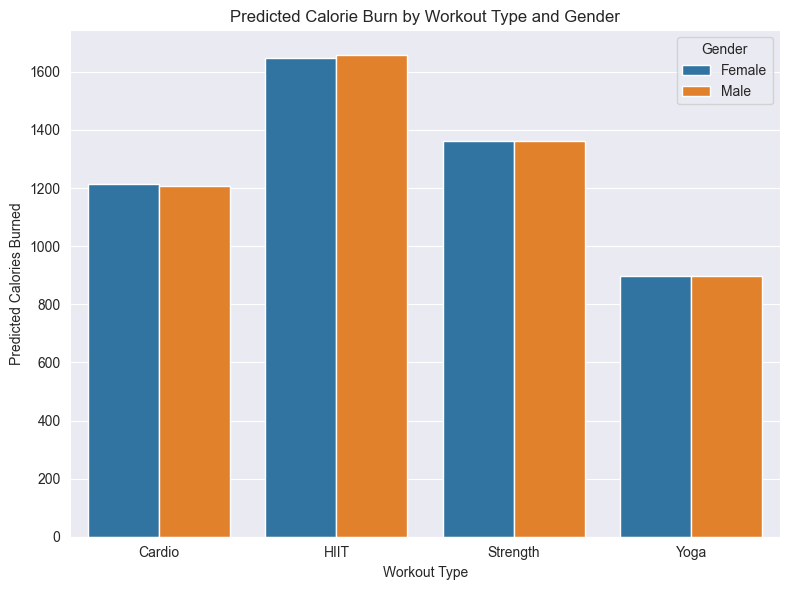

  Workout_Type_Label Gender_Label  Predicted_Calories
0             Cardio       Female         1213.875652
1             Cardio         Male         1208.101066
2               HIIT       Female         1646.102453
3               HIIT         Male         1659.718994
4           Strength       Female         1362.941569
5           Strength         Male         1361.672207
6               Yoga       Female          895.938853
7               Yoga         Male          896.397138


In [78]:
import numpy as np
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

final_df = df = pd.read_csv(os.path.join(path, "Final_data.csv"))

features = [
    'Workout_Type', 'Gender', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage', 'Experience_Level',
]
target = 'Calories_Burned'

for col in ["Burns_Calories_Bin", "Burns_Calories_per_30_min_bc", "expected_burn"]:
    if col in df.columns:
        df.drop(columns=col, inplace=True)

# Drop rows with missing values in selected columns
final_df_pred = final_df[features + [target]].dropna()

# Encode categorical variables
le_workout = LabelEncoder()
le_gender = LabelEncoder()
le_experience = LabelEncoder()

final_df_pred['Workout_Type_enc'] = le_workout.fit_transform(final_df_pred['Workout_Type'])
final_df_pred['Gender_enc'] = le_gender.fit_transform(final_df_pred['Gender'])
final_df_pred['Experience_Level_enc'] = le_experience.fit_transform(final_df_pred['Experience_Level'])

# Prepare feature matrix X and target vector y
X = final_df_pred[['Workout_Type_enc', 'Gender_enc', 'Age', 'Weight (kg)', 'Height (m)', 'BMI', 'Fat_Percentage',
             ]]
y = final_df_pred[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict on test set
y_pred = rf.predict(X_test)

# Analyze predicted calorie burn by workout type and gender
final_df_pred['Predicted_Calories'] = rf.predict(X)
final_df_pred['Workout_Type_Label'] = le_workout.inverse_transform(final_df_pred['Workout_Type_enc'])
final_df_pred['Gender_Label'] = le_gender.inverse_transform(final_df_pred['Gender_enc'])

summary = final_df_pred.groupby(['Workout_Type_Label', 'Gender_Label'])['Predicted_Calories'].mean().reset_index()

# Calculate evaluation metrics
r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
 
print(f"R2 Score: {r2:.2f}")
print(f"Mean Absolute Error: {mae:.2f}")
print(f"Mean Squared Error: {mse:.2f}")

plt.figure(figsize=(8,6))
sns.barplot(data=summary, x='Workout_Type_Label', y='Predicted_Calories', hue='Gender_Label')
plt.title('Predicted Calorie Burn by Workout Type and Gender')
plt.ylabel('Predicted Calories Burned')
plt.xlabel('Workout Type')
plt.legend(title='Gender')
plt.tight_layout()
plt.show()

print(summary)


### Model Justification and Exploration of Results

| Metric | Value |
|:--------|:------:|
| **R² Score** | **0.84** |
| **Mean Absolute Error (MAE)** | **126.40 calories** |
| **Mean Squared Error (MSE)** | **39581.73** |

**Interpretation**
- The Random Forest model achieved R² = 0.84, indicating that the input variables explain a large portion of the variation in calorie burn, but not all of it.
- The MAE of 126 calories and MSE of 39,581 show that predictions are reasonably close to the true values, with errors consistent with real-world physiological variability.

**Insights from the visual**
- **HIIT** sessions produced the **highest predicted calorie burn** (~1660 kcal), followed by **Strength**, **Cardio**, and **Yoga**.  
- Gender differences were minimal, both male and female predictions were nearly identical across all workout types.  
- This indicates that **workout type** drives calorie burn more than gender in this dataset.

**Summary**
- **HIIT** is the most calorie-intensive activity, while **Yoga** yields the lowest burn.  
- The similarity between genders suggests comparable energy expenditure when controlling for session duration and body composition.  
- Overall, the Random Forest model captures the relationships effectively, providing strong evidence of how workout intensity and type influence calorie output.
